In [1]:
from tile_mate import get_raster_from_tiles
from dem_stitcher.rio_tools import reproject_arr_to_match_profile
from dist_s1_enumerator.mgrs_burst_data import get_mgrs_table
import numpy as np
import rasterio
from dist_s1.rio_tools import get_mgrs_profile
from dem_stitcher.rio_tools import translate_profile
from dem_stitcher.merge import merge_arrays_with_geometadata
from shapely.geometry import box
import matplotlib.pyplot as plt

/Users/cmarshak/miniforge3/envs/dist-s1-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Good and Bad Water masks

Get a water mask that is buffered by quarter degree around MGRS tile and one that is contained within it.

In [2]:
def get_water_mask_from_glad(xmin, ymin, xmax, ymax):
    X_glad_lc, p_glad_lc = get_raster_from_tiles([xmin, ymin, xmax, ymax], tile_shortname='glad_landcover', year=2020)

    # open water classes
    water_labels = [k for k in range(203, 208)]  # These are pixels that have surface water at least 50% of the time.
    water_labels.extend(
        [
            254,  # ocean
            255,  # no data
        ]
    )
    X_water_glad = np.isin(X_glad_lc[0, ...], water_labels).astype(np.uint8)

    return X_water_glad, p_glad_lc

In [3]:
df_mgrs = get_mgrs_table()
df_mgrs.head()

,mgrs_tile_id,utm_epsg,utm_wkt,geometry
0,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688..."
1,01FBF,32701,"MULTIPOLYGON(((199980 4600000,199980 4490200,3...","MULTIPOLYGON (((-179.58653 -48.72398, -179.638..."
2,01GBH,32701,"MULTIPOLYGON(((199980 4800040,199980 4690240,3...","MULTIPOLYGON (((-179.49865 -46.9259, -179.5458..."
3,01GDM,32701,"MULTIPOLYGON(((399960 5200000,399960 5090200,5...","POLYGON ((-178.23431 -43.34619, -178.25485 -44..."
4,01GEL,32701,"MULTIPOLYGON(((499980 5100040,499980 4990240,6...","POLYGON ((-177.00025 -44.25288, -177.00025 -45..."


In [4]:
df_tile = df_mgrs[df_mgrs.mgrs_tile_id=='17SLR'].reset_index(drop=True)
df_tile

,mgrs_tile_id,utm_epsg,utm_wkt,geometry
0,17SLR,32617,"MULTIPOLYGON(((300000 3600000,300000 3490200,4...","POLYGON ((-83.12928 32.51933, -83.1065 31.5294..."


In [5]:
df_tile.iloc[0].geometry.buffer(-.1).bounds

(-83.02698478153843, 31.630590315046998, -82.05127962719526, 32.43246362892555)

In [6]:
bounds_buffered_quarter_deg = df_tile.iloc[0].geometry.buffer(.25).bounds
bounds_buffered_minus_quarter_deg = df_tile.iloc[0].geometry.buffer(-.25).bounds

In [7]:
X_wm_good, p_wm_good = get_water_mask_from_glad(*bounds_buffered_quarter_deg)

Reading tile imagery: 100%|██████████████████████| 1/1 [00:23<00:00, 23.92s/it]


In [8]:
X_wm_bad, p_wm_bad = get_water_mask_from_glad(*bounds_buffered_minus_quarter_deg)

Reading tile imagery: 100%|██████████████████████| 1/1 [00:06<00:00,  6.75s/it]


In [9]:
with rasterio.open('17SLR_good_water_mask.tif', 'w', **p_wm_bad) as ds:
    ds.write(X_wm_good, 1)

In [10]:
with rasterio.open('17SLR_bad_water_mask.tif', 'w', **p_wm_bad) as ds:
    ds.write(X_wm_bad, 1)

# Generate a water Mask around the dateline

In [11]:
df_tile_antimeridian = df_mgrs[df_mgrs.mgrs_tile_id == '01VCK'].reset_index(drop=True)
df_tile_antimeridian.geometry = df_tile_antimeridian.geometry.buffer(.25).intersection(box(-180, -90, 180, 90))
df_tile_antimeridian.head()

/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_40547/3978929101.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_tile_antimeridian.geometry = df_tile_antimeridian.geometry.buffer(.25).intersection(box(-180, -90, 180, 90))


,mgrs_tile_id,utm_epsg,utm_wkt,geometry
0,01VCK,32601,"MULTIPOLYGON(((300000 7000020,300000 6890220,4...","MULTIPOLYGON (((179.14923 61.84165, 179.12509 ..."


In [12]:
bounds = []
for geo in df_tile_antimeridian.geometry.iloc[0].geoms:
    bounds.append(geo.bounds)
bounds = list(reversed(sorted(bounds, key=lambda b: b[0])))
bounds

[(178.789747498357, 61.84095826550357, 180.0, 63.34361041000481),
 (-180.0, 61.85768048122225, -178.48003797368202, 63.36819868273129)]

In [13]:
X_wm_0, p_wm_0 = get_water_mask_from_glad(*bounds[0])
X_wm_1, p_wm_1 = get_water_mask_from_glad(*bounds[1])

Reading tile imagery: 100%|██████████████████████| 1/1 [00:00<00:00,  1.12it/s]


In [14]:
360 / p_wm_0['transform'].a

1440000.0

In [15]:
p_wm_0_t = translate_profile(p_wm_0, -360 / p_wm_0['transform'].a, 0)
p_wm_0_t['transform']

Affine(0.00025, 0.0, -181.2105,
       0.0, -0.00025, 63.34375)

In [16]:
p_wm_0_t['nodata'] = 255
p_wm_1['nodata'] = 255

In [17]:
X_wm_merged, p_wm_merged = merge_arrays_with_geometadata([X_wm_0, X_wm_1], [p_wm_0_t, p_wm_1], method='max')
X_wm_merged = X_wm_merged[0, ...]

In [18]:
with rasterio.open('01VCK_water_mask_antimeridian.tif', 'w', **p_wm_merged) as ds:
    ds.write(X_wm_merged,1)

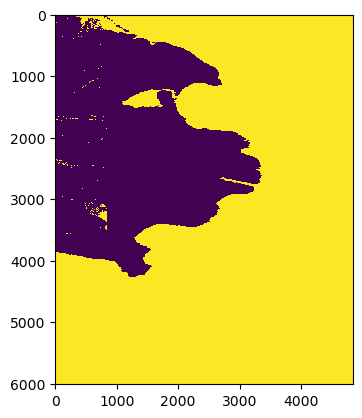

In [19]:
plt.imshow(X_wm_0, interpolation='none')

In [20]:
X_plot = X_wm_merged.astype(np.float32)
X_plot[X_plot == 255] = np.nan

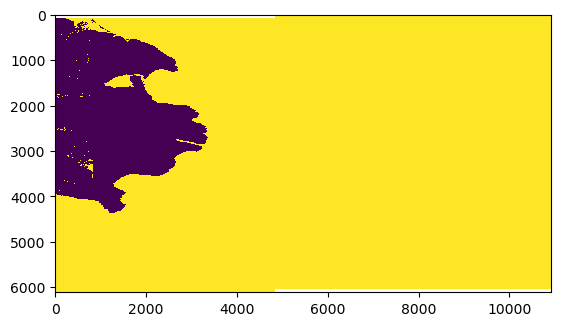

In [21]:
plt.imshow(X_plot, interpolation='none')